# Iteration Visualization
Use this notebook to interactively reproduce every plot for a saved active-learning iteration. Configure the toggles below to control figure saving, plotting style, and whether 3D axes use the interactive widget backend.

In [25]:
# --- Visualization toggles ---
SAVE_FIGURES = False            # set False to skip writing PNGs
USE_INTERACTIVE_3D = True      # set False for static inline 3D plots
ENTROPY_PLOT_MODE = "scatter"  # options: 'scatter', 'contour', 'surface'
ENTROPY_AGGREGATION = "mean"   # used when ENTROPY_PLOT_MODE != 'scatter' and ENTROPY_T_SLICE is None
ENTROPY_T_SLICE = None          # set to an integer to view a specific temperature slice instead of aggregating

In [26]:
ip = get_ipython()
if ip is not None:
    backend = "widget" if USE_INTERACTIVE_3D else "inline"
    ip.run_line_magic("matplotlib", backend)

In [27]:
import json
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import tri
from gpytorch.likelihoods import DirichletClassificationLikelihood
from botorch.models.transforms import Normalize

from modules import (
    SRSFHilbertSphere,
    DirichletGPModel,
    batch_acqusition_xy,
)
from visuals import plot_function_optimization, plot_active_learning_data

In [28]:
ARTIFACT_DIR = Path("results_111725/artifacts").resolve()
STATIC_GRID_PATH = ARTIFACT_DIR / "static_grids.npz"
METADATA_PATH = ARTIFACT_DIR / "metadata.json"
FIGURE_OUTPUT_DIR = ARTIFACT_DIR.parent / "figures_recreated"
if SAVE_FIGURES:
    FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(METADATA_PATH) as fp:
    METADATA = json.load(fp)

with np.load(STATIC_GRID_PATH) as data:
    GRID_DATA = {k: data[k] for k in data.files}

BOUNDS = torch.tensor(METADATA["bounds"], dtype=torch.float32)
BOUNDS_T = BOUNDS[:, -1]
MANIFOLD = SRSFHilbertSphere(**METADATA["config"]["manifold"])

In [29]:
def load_iteration_bundle(iter_num: int):
    path = ARTIFACT_DIR / f"iter_{iter_num:04d}.npz"
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact file: {path}")
    with np.load(path) as data:
        return {k: data[k] for k in data.files}

In [30]:
# Choose which iteration to visualize
iteration = 25

In [31]:
bundle = load_iteration_bundle(iteration)
grid_xyz = GRID_DATA["grid_xyz"]
grid_xy = GRID_DATA["grid_xy"]
grid_t = GRID_DATA["grid_t"]
print(f"Loaded iteration {iteration} with {grid_xyz.shape[0]} grid points and {len(bundle['active_learning.train_X'])} experiments")

Loaded iteration 25 with 2500 grid points and 98 experiments


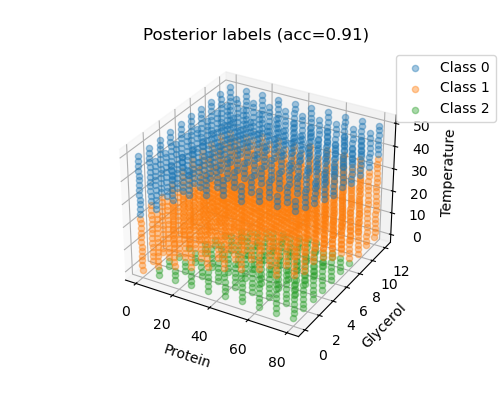

In [32]:
labels = bundle["posterior.labels"]
accuracy = float(bundle["posterior.accuracy"])
fig_labels = plt.figure(figsize=(5, 4))
ax_labels = fig_labels.add_subplot(111, projection="3d")
for l in np.unique(labels):
    mask = labels == l
    ax_labels.scatter(
        grid_xyz[mask, 0],
        grid_xyz[mask, 1],
        grid_xyz[mask, 2],
        s=20,
        depthshade=False,
        alpha=0.4,
        label=f"Class {int(l)}",
    )
ax_labels.set_xlabel("Protein")
ax_labels.set_ylabel("Glycerol")
ax_labels.set_zlabel("Temperature")
ax_labels.set_title(f"Posterior labels (acc={accuracy:.2f})")
ax_labels.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
if SAVE_FIGURES:
    fig_labels.savefig(FIGURE_OUTPUT_DIR / f"iter_{iteration:04d}_posterior_labels.png", dpi=200, bbox_inches="tight")

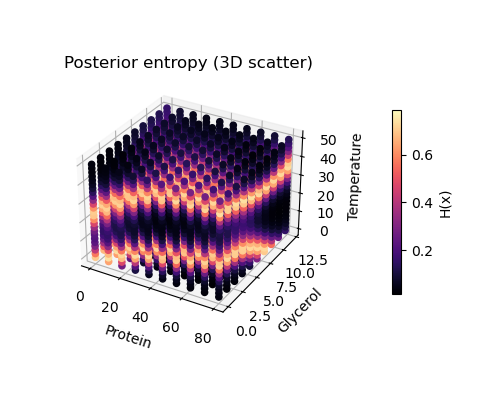

In [43]:
entropy = bundle["posterior.entropy"]
if ENTROPY_PLOT_MODE.lower() == "scatter":
    fig_entropy = plt.figure(figsize=(5, 4))
    ax_entropy = fig_entropy.add_subplot(111, projection="3d")
    ent_plot = ax_entropy.scatter(
        grid_xyz[:, 0],
        grid_xyz[:, 1],
        grid_xyz[:, 2],
        c=entropy,
        cmap="magma",
        s=20,
        depthshade=False,
    )
    ax_entropy.set_xlabel("Protein")
    ax_entropy.set_ylabel("Glycerol")
    ax_entropy.set_zlabel("Temperature")
    ax_entropy.set_title("Posterior entropy (3D scatter)")
    fig_entropy.colorbar(ent_plot, ax=ax_entropy, shrink=0.6, pad=0.2, label="H(x)")
else:
    entropy_grid = entropy.reshape(len(grid_xy), len(grid_t))
    if ENTROPY_T_SLICE is not None:
        idx = int(np.clip(ENTROPY_T_SLICE, 0, entropy_grid.shape[1] - 1))
        entropy_field = entropy_grid[:, idx]
        title_suffix = f"slice idx {idx}"
    else:
        agg = ENTROPY_AGGREGATION.lower()
        if agg == "max":
            entropy_field = entropy_grid.max(axis=1)
        elif agg == "min":
            entropy_field = entropy_grid.min(axis=1)
        else:
            entropy_field = entropy_grid.mean(axis=1)
        title_suffix = f"{agg} across temperature"
    tri_xy = tri.Triangulation(grid_xy[:, 0], grid_xy[:, 1])
    mode = ENTROPY_PLOT_MODE.lower()
    if mode == "contour":
        fig_entropy, ax_entropy = plt.subplots(figsize=(5, 4))
        contour = ax_entropy.tricontourf(tri_xy, entropy_field, cmap="magma")
        ax_entropy.set_xlabel("Protein")
        ax_entropy.set_ylabel("Glycerol")
        ax_entropy.set_title(f"Posterior entropy contour ({title_suffix})")
        fig_entropy.colorbar(contour, ax=ax_entropy, label="H(x)")
    else:
        fig_entropy = plt.figure(figsize=(5, 4))
        ax_entropy = fig_entropy.add_subplot(111, projection="3d")
        surf = ax_entropy.plot_trisurf(tri_xy, entropy_field, cmap="magma", linewidth=0.2, antialiased=True)
        ax_entropy.set_xlabel("Protein")
        ax_entropy.set_ylabel("Glycerol")
        ax_entropy.set_zlabel("Entropy")
        ax_entropy.set_title(f"Posterior entropy surface ({title_suffix})")
        fig_entropy.colorbar(surf, ax=ax_entropy, shrink=0.6, pad=0.25, label="H(x)")
if SAVE_FIGURES:
    suffix = ENTROPY_PLOT_MODE.lower()
    fig_entropy.savefig(FIGURE_OUTPUT_DIR / f"iter_{iteration:04d}_posterior_entropy_{suffix}.png", dpi=200, bbox_inches="tight")


/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_66568/4118914141.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("magma")


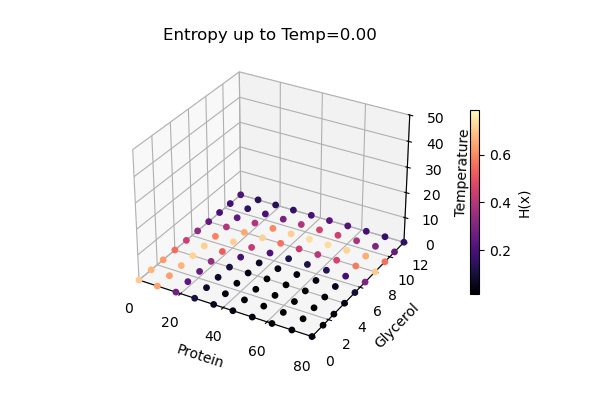

In [34]:

import ipywidgets as widgets
from IPython.display import display
from matplotlib import cm
from matplotlib.colors import Normalize

entropy_values = bundle["posterior.entropy"]
fig_entropy_slice, ax_entropy_slice = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(6, 4))
ax_entropy_slice.set_xlim(BOUNDS[:, 0].numpy())
ax_entropy_slice.set_ylim(BOUNDS[:, 1].numpy())
ax_entropy_slice.set_zlim(BOUNDS[:, 2].numpy())
color_norm = Normalize(vmin=float(entropy_values.min()), vmax=float(entropy_values.max()))
color_map = cm.get_cmap("magma")
_state = {"colorbar": None}
output = widgets.Output()

slider = widgets.FloatSlider(
    min=float(grid_t.min()),
    max=float(grid_t.max()),
    value=float(grid_t.min()),
    step=float(np.diff(grid_t).min()) if len(grid_t) > 1 else 1.0,
    description="Temp",
    continuous_update=False
)


def update_entropy_slice(temp_value: float):
    mask = grid_xyz[:, 2] <= temp_value + 1e-8
    if not np.any(mask):
        mask = grid_xyz[:, 2] == grid_xyz[:, 2].min()
    x = grid_xyz[mask, 0]
    y = grid_xyz[mask, 1]
    z = grid_xyz[mask, 2]
    c = entropy_values[mask]
    ax_entropy_slice.cla()
    ax_entropy_slice.set_xlim(BOUNDS[:, 0].numpy())
    ax_entropy_slice.set_ylim(BOUNDS[:, 1].numpy())
    ax_entropy_slice.set_zlim(BOUNDS[:, 2].numpy())
    scatter = ax_entropy_slice.scatter(
        x,
        y,
        z,
        c=c,
        cmap=color_map,
        norm=color_norm,
        s=15,
        depthshade=False,
    )
    ax_entropy_slice.set_xlabel("Protein")
    ax_entropy_slice.set_ylabel("Glycerol")
    ax_entropy_slice.set_zlabel("Temperature")
    ax_entropy_slice.set_title(f"Entropy up to Temp={temp_value:.2f}")
    if _state["colorbar"] is None:
        sm = cm.ScalarMappable(norm=color_norm, cmap=color_map)
        sm.set_array([])
        _state["colorbar"] = fig_entropy_slice.colorbar(sm, ax=ax_entropy_slice, shrink=0.6, pad=0.1, label="H(x)")
    if USE_INTERACTIVE_3D:
        fig_entropy_slice.canvas.draw_idle()
    else:
        with output:
            output.clear_output(wait=True)
            display(fig_entropy_slice)


def _on_slider(change):
    if change.get("name") == "value" and change.get("new") is not None:
        update_entropy_slice(change["new"])

slider.observe(_on_slider, names="value")
update_entropy_slice(slider.value)
display(widgets.VBox([slider, output]))

In [ ]:
gp_state_file = ARTIFACT_DIR / "models" / f"iter_{iteration:04d}_gp.pt"
if not gp_state_file.exists():
    raise FileNotFoundError(f"Missing GP state file: {gp_state_file}")

state_dict = torch.load(gp_state_file, map_location="cpu")
train_X_tensor = torch.from_numpy(bundle["active_learning.train_X"]).float()
train_Y_tensor = torch.from_numpy(bundle["active_learning.train_Y"]).long()
likelihood_vis = DirichletClassificationLikelihood(
    train_Y_tensor.squeeze(),
    learn_additional_noise=True,
)
model_vis = DirichletGPModel(
    train_X_tensor,
    likelihood_vis.transformed_targets,
    likelihood_vis,
    num_classes=likelihood_vis.num_classes,
    transform=Normalize(d=3, bounds=BOUNDS),
)
model_vis.load_state_dict(state_dict["model_state_dict"])
likelihood_vis.load_state_dict(state_dict["likelihood_state_dict"])
model_vis.eval()
likelihood_vis.eval()


def acquisition_function(xy):
    xy_tensor = torch.as_tensor(xy, dtype=torch.float32).view(-1, 2)
    with torch.no_grad():
        values = batch_acqusition_xy(
            xy_tensor,
            model_vis,
            MANIFOLD,
            BOUNDS_T,
            n_samples=METADATA["config"]["optimize_xy"]["n_samples"],
        )
    return values


print(f"Loaded GP model from {gp_state_file}")
example_acq = acquisition_function(grid_xy[:5])
print("Sample acquisition values:", example_acq.view(-1).tolist())

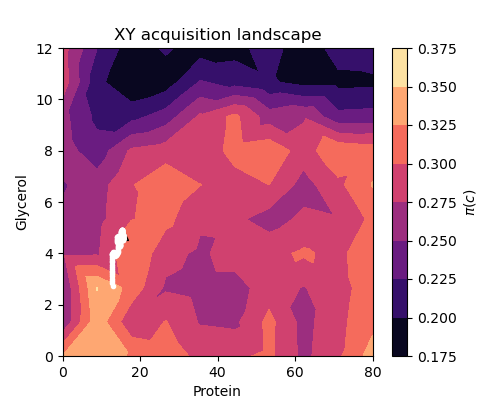

In [35]:
score_xy = bundle["acquisition_xy.scores"]
xy_star = np.atleast_2d(bundle["acquisition_xy.xy_star"])
trajectory_xy = bundle["acquisition_xy.trajectory"]
triangulation = tri.Triangulation(grid_xy[:, 0], grid_xy[:, 1])
fig_acq, ax_acq = plt.subplots(figsize=(5, 4))
contour = ax_acq.tricontourf(triangulation, score_xy, cmap="magma")
ax_acq.plot(trajectory_xy[:, 0], trajectory_xy[:, 1], "o-", color="w", lw=1.2, markersize=3)
ax_acq.scatter(xy_star[:, 0], xy_star[:, 1], marker="^", c="w", edgecolor="k", s=50)
ax_acq.set_xlabel("Protein")
ax_acq.set_ylabel("Glycerol")
ax_acq.set_title("XY acquisition landscape")
fig_acq.colorbar(contour, ax=ax_acq, label=r"$\pi(c)$")
if SAVE_FIGURES:
    fig_acq.savefig(FIGURE_OUTPUT_DIR / f"iter_{iteration:04d}_acquisition_xy.png", dpi=200, bbox_inches="tight")

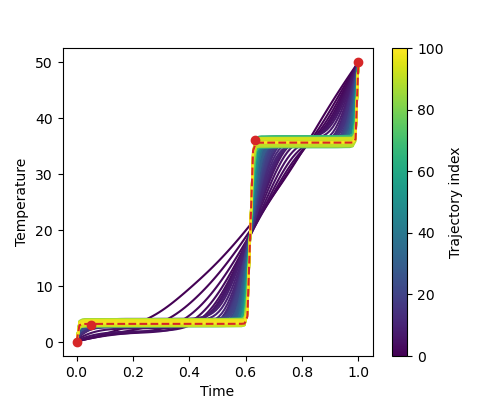

In [36]:
trajectory_tensor = torch.from_numpy(bundle["function_opt.trajectory"]).float()
if trajectory_tensor.ndim == 2:
    trajectory_tensor = trajectory_tensor.unsqueeze(-1)
profile = SimpleNamespace(
    x=bundle["function_opt.profile_time"],
    fx=bundle["function_opt.profile_temperature"],
)
fig_func, ax_func = plt.subplots(figsize=(5, 4))
plot_function_optimization(MANIFOLD, profile, trajectory_tensor, BOUNDS_T, ax=ax_func)
if SAVE_FIGURES:
    fig_func.savefig(FIGURE_OUTPUT_DIR / f"iter_{iteration:04d}_function_optimization.png", dpi=200, bbox_inches="tight")

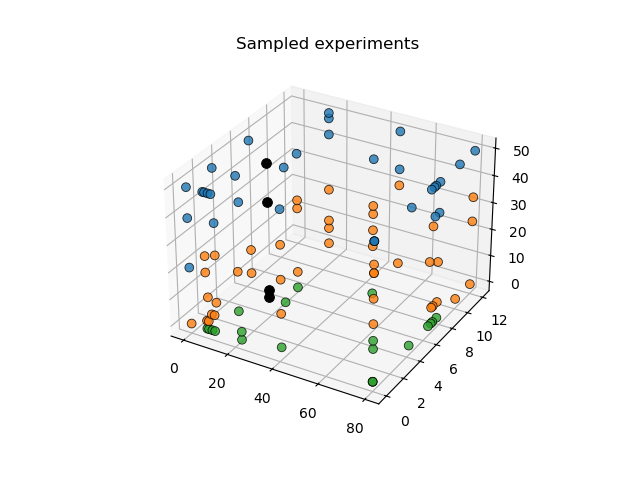

In [37]:
train_X = torch.from_numpy(bundle["active_learning.train_X"]).float()
train_Y = torch.from_numpy(bundle["active_learning.train_Y"]).float()
xy_star_tensor = torch.from_numpy(np.atleast_2d(bundle["active_learning.xy_star"])).float()
temperatures = torch.from_numpy(bundle["active_learning.proposed_temperatures"]).float()
fig_al, ax_al = plot_active_learning_data(train_X, train_Y, xy_star_tensor, temperatures)
ax_al.set_title("Sampled experiments")
if SAVE_FIGURES:
    fig_al.savefig(FIGURE_OUTPUT_DIR / f"iter_{iteration:04d}_active_learning.png", dpi=200, bbox_inches="tight")

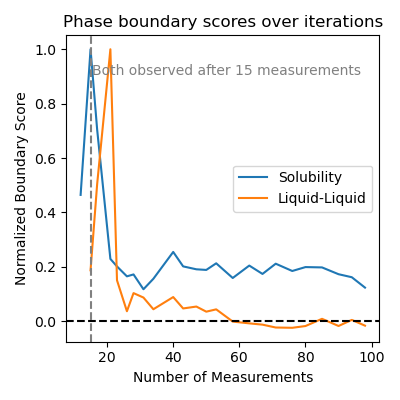

In [ ]:
fig, ax = plot_geodesic_progress(
    bundle["active_learning.batch_indices"],
    ARTIFACT_DIR / "geodesic_scores.jsonl"
    )
if SAVE_FIGURES:
    fig.savefig(FIGURE_OUTPUT_DIR / f"scores.png", dpi=200, bbox_inches="tight")